# Problem presentation
### Identifying weather regimes using unsupervised learning
In this example we will use unsupervised learning to classify sea level pressure data into different "weather regimes". They allow to understand long term weather patterns.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib 
import pandas as pd
import xarray as xr
import seaborn as sns
import cartopy.crs as ccrs

import sklearn
# Test whether the notebook is running on google colab or not, and set the data path accordingly
import os
if os.getenv("COLAB_RELEASE_TAG") is None:
    DATA_IN_PATH = '../data'
else:
    DATA_IN_PATH = 'https://raw.githubusercontent.com/rguilcas/BCCR-ML-course/refs/heads/main/lecture_exercises/data'

# STEP 1: Load and preprocess data
We use data from ERA5 which gives a grid over the entire world. We only focus on North Atlantic data.
The data is already prepared for you.


In [ ]:
ds = xr.open_dataarray(f'{DATA_IN_PATH}/msl_data_northatlantic.nc')
longitude = ds.longitude
latitude = ds.latitude

In [3]:
X = ds.values
print(X.shape)

(3701, 31, 66)


### We can plot an example data point:

/opt/anaconda3/envs/bccr-ml/lib/python3.13/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/bccr-ml/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/bccr-ml/lib/python3.13/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/bccr-ml/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/bccr-ml/lib/python3.13/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


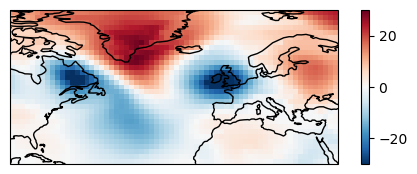

In [4]:
sample_to_plot = X[20]

fig, ax = plt.subplots(figsize=(6,2), subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.coastlines()
im = ax.pcolormesh( longitude, latitude, sample_to_plot, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin=-30, vmax=30)
fig.colorbar(im, ax=ax)

## Note that we are using an **unsupervised** algorithm, there is no `y` data.

We need to flatten the data for this task. We will talk about reshaping data later.

In [5]:
X = X.reshape(-1, np.prod(X.shape[1:]))
print(X.shape)

(3701, 2046)


## **QUESTION 1**: Create train, validation and test datasets from `X`

In [6]:
X_train, X_valtest = sklearn.model_selection.train_test_split(X, train_size=0.7)
X_val, X_test = sklearn.model_selection.train_test_split(X_valtest, train_size=0.7)

# STEP 2: Define ML model and fit it to the data


## **QUESTION 2**: Define the KMeans model by creating the object `model` in the following cell.
There is one hyperparameter we can change here: `n_clusters`, it corresponds to the number of classes we want to split the data in. Choose what you feel appropriate.

In [7]:
n_clusters = 5
model = sklearn.cluster.KMeans(n_clusters=n_clusters)
model

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


## Step 2.2: Fit the model to the data
Once we have defined the model, we will fit the model to the data. The model will change some internal coefficients to determine the cluster centers.

## **QUESTION 3**: Fit the model to the **training data** in the following cell.

In [8]:
model.fit(X_train)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


## Plot the centroid of the clusters

/opt/anaconda3/envs/bccr-ml/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/bccr-ml/lib/python3.13/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


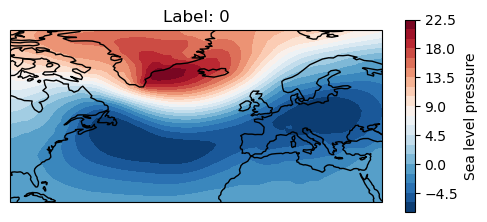

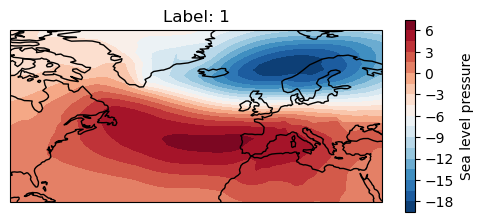

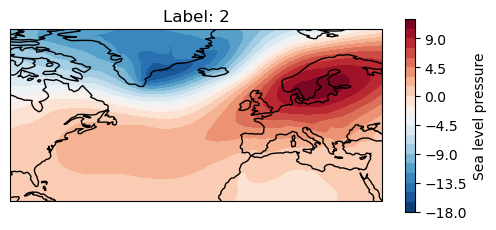

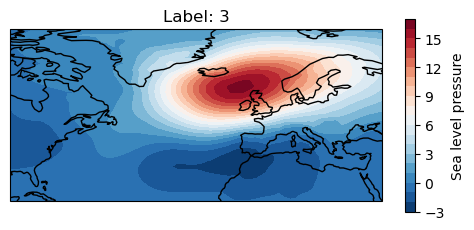

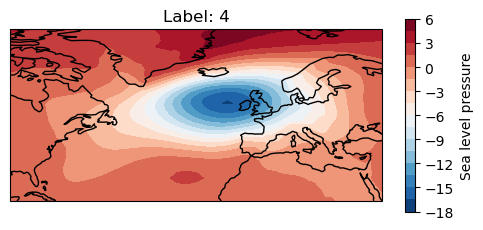

In [9]:
for k in range(n_clusters):
    fig, ax = plt.subplots(figsize=(6,2.5), subplot_kw=dict(projection=ccrs.PlateCarree()))
    pattern = model.cluster_centers_[k].reshape(len(ds.latitude), len(ds.longitude))
    contour = ax.contourf(ds.longitude, ds.latitude, pattern, cmap='RdBu_r', transform=ccrs.PlateCarree(), levels=20)
    ax.coastlines()
    ax.set_title(f"Label: {k:.0f}")
    fig.colorbar(contour, label='Sea level pressure')

# STEP 3: Make predictions and evaluate the model skill
Once the model is fitted to the data, we can use it to make predictions of clusters.

## Step 3.1: Predict clusters for `X`
We predict the clusters of `X` for the validation dataset.

## **QUESTION 4**: Use the **validation data** to predict clusters.

In [10]:
val_cluster = model.predict(X_val)

## Evaluate the results with `silhouette_score`.
The silouhette score is a way to quantify the skill of a clustering algorithm. For more details see the bonus slides!
You can compute it by using `sklearn.metrics.silhouette_score(X, clusters)`. It is between -1 and 1 and should be closer to 1.

## **QUESTION 5**: Compute the silhouette score of the validation data.

In [11]:
silhouette = sklearn.metrics.silhouette_score(X_val, val_cluster)
print(f"Silhouette score: {silhouette:.02f}")

Silhouette score: 0.09


## **QUESTION 6**: Change the number of clusters and compare results.
Is there an optimal number of clusters? You can plot the silouhette score depending on the number of clusters chosen

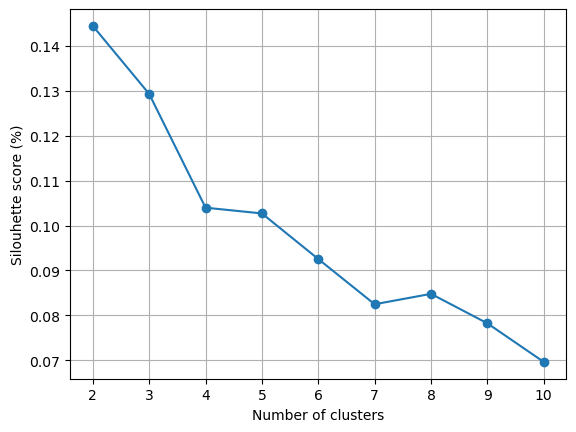

In [12]:
all_silhouette = []
for n_clusters in range(2, 11):
    model = sklearn.cluster.KMeans(n_clusters=n_clusters)
    model.fit(X_train)
    val_cluster = model.predict(X_val)    
    silhouette = sklearn.metrics.silhouette_score(X_val, val_cluster)
    all_silhouette.append(silhouette)

fig, ax = plt.subplots()
ax.plot(np.arange(2,11), all_silhouette, marker='o')
ax.set_ylabel('Silouhette score (%)')
ax.set_xlabel('Number of clusters')
ax.grid()